## 1. Setup and Imports

In [2]:
import os
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import random

# Paths
BASE_DIR = Path("../data")
SECTIONS_DIR = BASE_DIR / "quiz_sections"
OUTPUT_DIR = BASE_DIR / "individual_priorities"

print(f"Sections directory: {SECTIONS_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

# Find all test directories
if SECTIONS_DIR.exists():
    test_dirs = sorted([d for d in SECTIONS_DIR.iterdir() if d.is_dir()])
    print(f"\nFound {len(test_dirs)} test directories")
else:
    print(f"ERROR: {SECTIONS_DIR} does not exist!")
    test_dirs = []

Sections directory: ..\data\quiz_sections
Output directory: ..\data\individual_priorities

Found 20 test directories


## 2. Load Sample Image and Display with Grid

Let's load a sample priority image and display it with grid lines to help determine the margins.

Sample image: test-01_priorities.png
Image shape: (888, 1024, 3)
Height: 888 px
Width: 1024 px


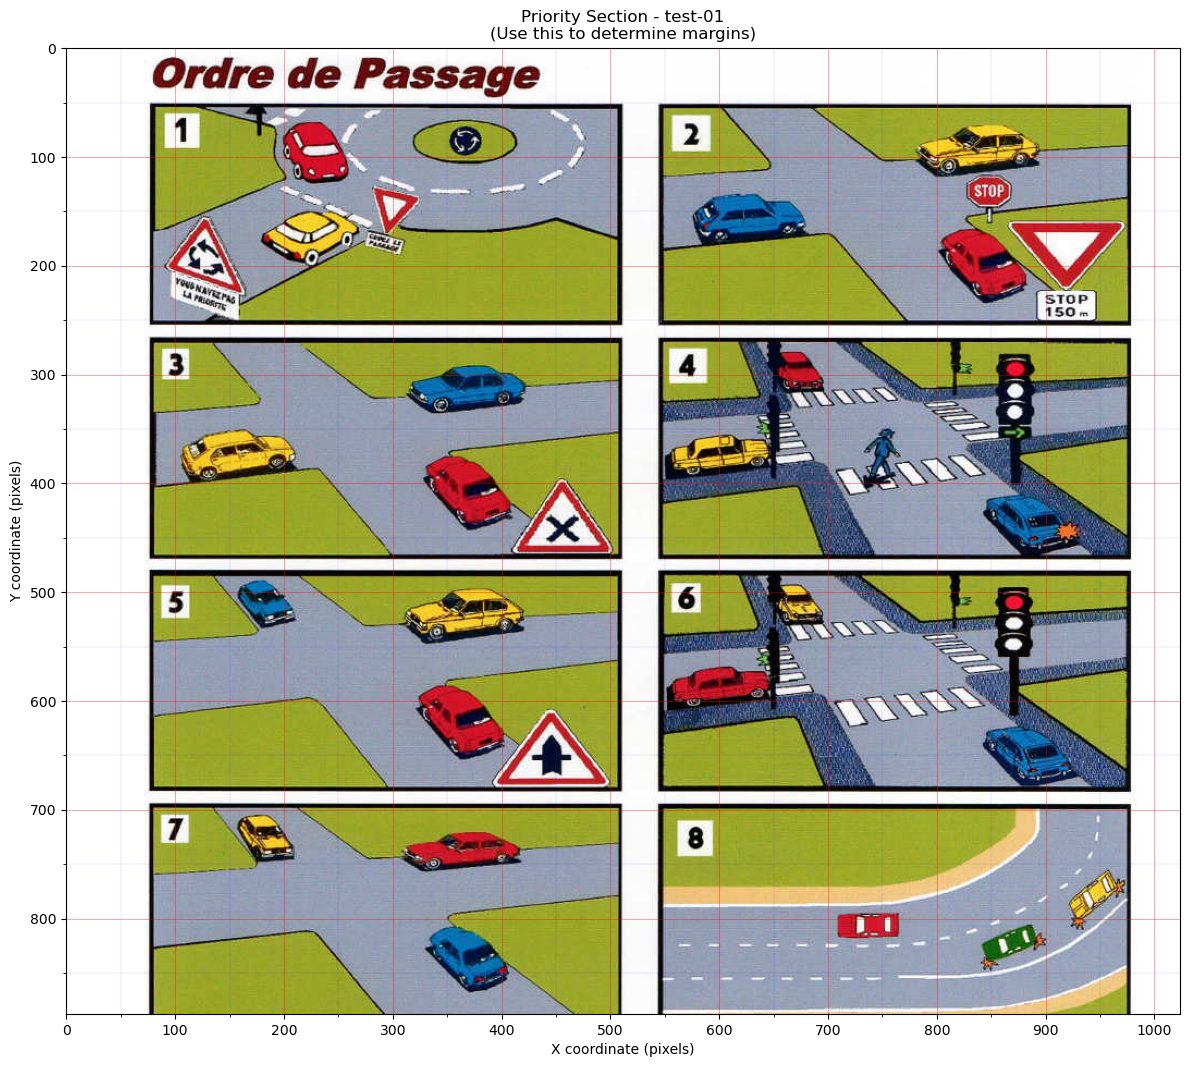

In [3]:
# Load a sample priority image
if test_dirs:
    sample_test = test_dirs[0]
    sample_priorities_dir = sample_test / "PRIORITIES"
    
    if sample_priorities_dir.exists():
        priorities_files = list(sample_priorities_dir.glob("*.png"))
        
        if priorities_files:
            sample_img_path = priorities_files[0]
            sample_img = cv2.imread(str(sample_img_path))
            
            print(f"Sample image: {sample_img_path.name}")
            print(f"Image shape: {sample_img.shape}")
            print(f"Height: {sample_img.shape[0]} px")
            print(f"Width: {sample_img.shape[1]} px")
            
            # Display with coordinate grid
            plt.figure(figsize=(12, 16))
            plt.imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
            plt.title(f"Priority Section - {sample_test.name}\n(Use this to determine margins)")
            plt.xlabel('X coordinate (pixels)')
            plt.ylabel('Y coordinate (pixels)')
            plt.grid(True, alpha=0.5, linewidth=0.5, color='red')
            
            # Add major gridlines every 100 pixels
            ax = plt.gca()
            ax.set_xticks(range(0, sample_img.shape[1], 100))
            ax.set_yticks(range(0, sample_img.shape[0], 100))
            
            # Add minor gridlines every 50 pixels
            ax.set_xticks(range(0, sample_img.shape[1], 50), minor=True)
            ax.set_yticks(range(0, sample_img.shape[0], 50), minor=True)
            ax.grid(which='minor', alpha=0.2, linewidth=0.3, color='blue')
            ax.grid(which='major', alpha=0.5, linewidth=0.5, color='red')
            
            plt.tight_layout()
            plt.show()
        else:
            print("No priority images found!")
    else:
        print(f"PRIORITIES directory not found in {sample_test.name}")
else:
    print("No test directories found!")

## 2b. Measure Cell Dimensions

Draw a sample grid to measure the width and height of individual priority cells.

Testing cell dimensions:
  Cell Width: 450 px
  Cell Height: 180 px
  Horizontal Spacing: 50 px
  Vertical Spacing: 20 px

Priority 1: x=[68, 518], y=[50, 230], size=450x180
Priority 2: x=[568, 1018], y=[50, 230], size=450x180
Priority 3: x=[68, 518], y=[250, 430], size=450x180
Priority 4: x=[568, 1018], y=[250, 430], size=450x180
Priority 5: x=[68, 518], y=[450, 630], size=450x180
Priority 6: x=[568, 1018], y=[450, 630], size=450x180
Priority 7: x=[68, 518], y=[650, 830], size=450x180
Priority 8: x=[568, 1018], y=[650, 830], size=450x180


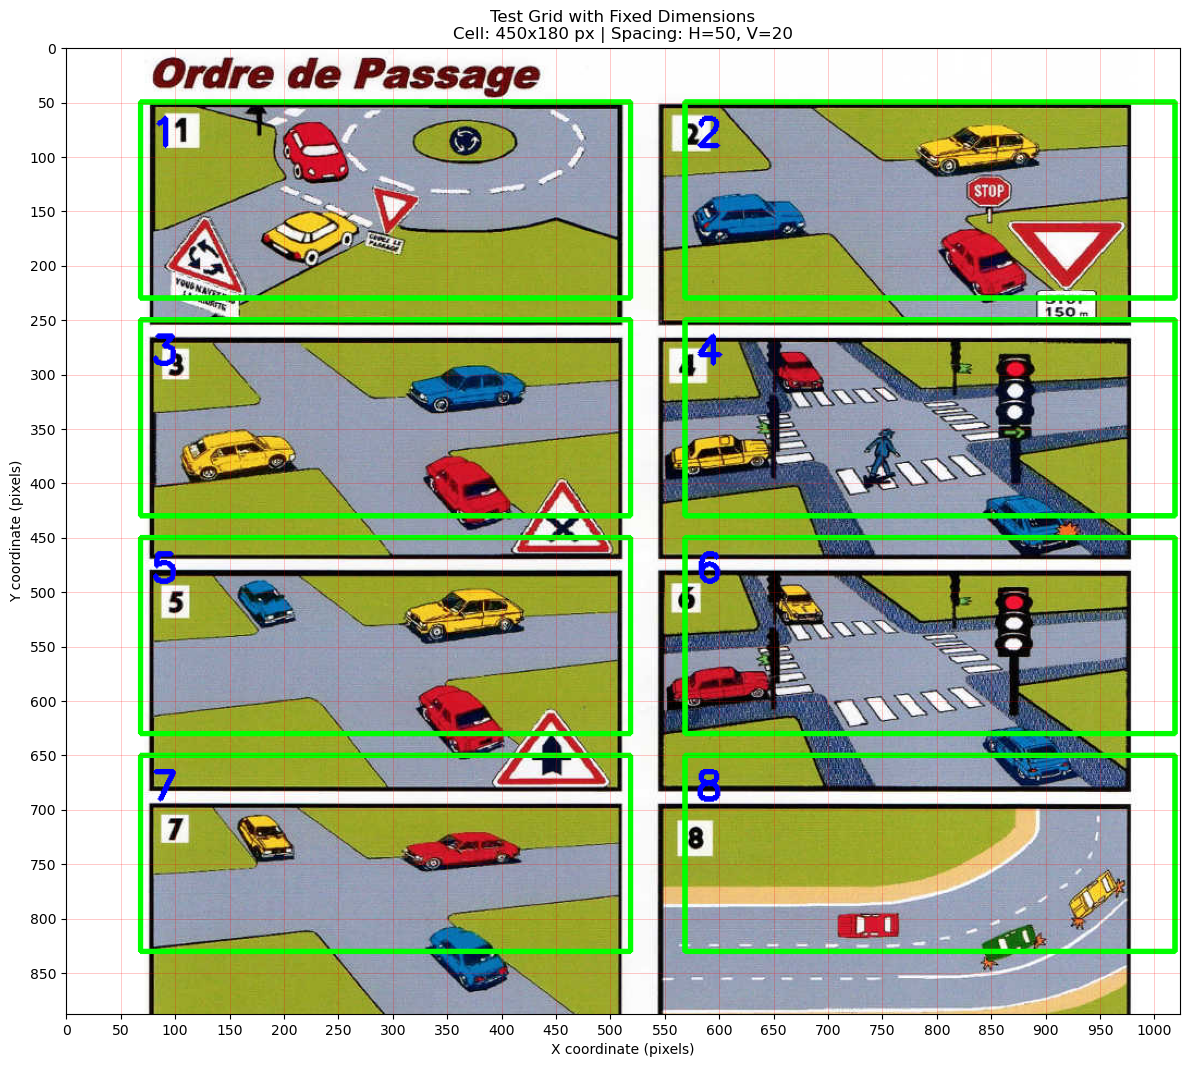

In [20]:
# Draw sample boxes to measure cell dimensions
if test_dirs:
    sample_test = test_dirs[0]
    sample_priorities_dir = sample_test / "PRIORITIES"
    
    if sample_priorities_dir.exists():
        priorities_files = list(sample_priorities_dir.glob("*.png"))
        
        if priorities_files:
            sample_img = cv2.imread(str(priorities_files[0]))
            img_copy = sample_img.copy()
            
            # Draw sample grid with test dimensions
            # You can adjust these values to find the right cell size
            TEST_TOP_MARGIN = 50
            TEST_LEFT_MARGIN = 68
            TEST_CELL_WIDTH = 450  # ADJUST THIS
            TEST_CELL_HEIGHT = 180  # ADJUST THIS
            TEST_H_SPACING = 50
            TEST_V_SPACING = 20
            
            print("Testing cell dimensions:")
            print(f"  Cell Width: {TEST_CELL_WIDTH} px")
            print(f"  Cell Height: {TEST_CELL_HEIGHT} px")
            print(f"  Horizontal Spacing: {TEST_H_SPACING} px")
            print(f"  Vertical Spacing: {TEST_V_SPACING} px\n")
            
            # Draw 4x2 grid
            for row in range(4):
                for col in range(2):
                    x_start = TEST_LEFT_MARGIN + col * (TEST_CELL_WIDTH + TEST_H_SPACING)
                    y_start = TEST_TOP_MARGIN + row * (TEST_CELL_HEIGHT + TEST_V_SPACING)
                    x_end = x_start + TEST_CELL_WIDTH
                    y_end = y_start + TEST_CELL_HEIGHT
                    
                    cv2.rectangle(img_copy, (x_start, y_start), (x_end, y_end), (0, 255, 0), 3)
                    cv2.putText(img_copy, str(row * 2 + col + 1), (x_start+10, y_start+40),
                               cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 0, 0), 3)
                    
                    print(f"Priority {row*2+col+1}: x=[{x_start}, {x_end}], y=[{y_start}, {y_end}], "
                          f"size={x_end-x_start}x{y_end-y_start}")
            
            # Display
            plt.figure(figsize=(12, 16))
            plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
            plt.title(f"Test Grid with Fixed Dimensions\n"
                     f"Cell: {TEST_CELL_WIDTH}x{TEST_CELL_HEIGHT} px | "
                     f"Spacing: H={TEST_H_SPACING}, V={TEST_V_SPACING}")
            plt.xlabel('X coordinate (pixels)')
            plt.ylabel('Y coordinate (pixels)')
            plt.grid(True, alpha=0.3, linewidth=0.5, color='red')
            
            ax = plt.gca()
            ax.set_xticks(range(0, sample_img.shape[1], 50))
            ax.set_yticks(range(0, sample_img.shape[0], 50))
            ax.grid(which='major', alpha=0.3, linewidth=0.5, color='red')
            
            plt.tight_layout()
            plt.show()
        else:
            print("No priority images found!")
    else:
        print("PRIORITIES directory not found!")
else:
    print("No test directories found!")

## 3. Fixed Grid Approach

Uses fixed proportions based on margins and equal division for 4 rows × 2 columns = 8 priorities.

### Parameters

In [49]:
# TWEAK THESE PARAMETERS
FIXED_TOP_MARGIN = 43
FIXED_BOTTOM_MARGIN = 0
FIXED_LEFT_MARGIN = 72
FIXED_RIGHT_MARGIN = 50
FIXED_HORIZONTAL_SPACING = 40
FIXED_VERTICAL_SPACING = 10

# Fixed cell dimensions (set to None to auto-calculate from image)
FIXED_CELL_WIDTH = 510 - 75   # e.g., 450
FIXED_CELL_HEIGHT = 200  # e.g., 180

EXPECTED_ROWS = 4
EXPECTED_COLS = 2

### Functions

In [50]:
def calculate_boxes_fixed_grid(img):
    """Calculate priority boxes using fixed grid division (4 rows × 2 cols)."""
    img_height, img_width = img.shape[0], img.shape[1]
    
    # Use fixed cell dimensions if provided, otherwise calculate from image
    if FIXED_CELL_WIDTH is not None and FIXED_CELL_HEIGHT is not None:
        cell_width = FIXED_CELL_WIDTH
        cell_height = FIXED_CELL_HEIGHT
    else:
        usable_height = img_height - FIXED_TOP_MARGIN - FIXED_BOTTOM_MARGIN
        usable_width = img_width - FIXED_LEFT_MARGIN - FIXED_RIGHT_MARGIN
        cell_width = usable_width // EXPECTED_COLS
        cell_height = usable_height // EXPECTED_ROWS
    
    boxes = []
    for row in range(EXPECTED_ROWS):
        for col in range(EXPECTED_COLS):
            x_start = FIXED_LEFT_MARGIN + col * (cell_width + FIXED_HORIZONTAL_SPACING)
            y_start = FIXED_TOP_MARGIN + row * (cell_height + FIXED_VERTICAL_SPACING)
            x_end = x_start + cell_width
            y_end = y_start + cell_height
            boxes.append((x_start, y_start, x_end, y_end))
    
    return boxes

## 4. Testing

Process all priority sections and crop into 8 individual images.

In [51]:
def crop_priorities(priorities_img_path, output_dir, test_name):
    """
    Crop priorities using fixed grid approach.
    Returns: (saved_paths, method_info)
    """
    img = cv2.imread(str(priorities_img_path))
    if img is None:
        return [], "error: cannot load image"
    
    boxes = calculate_boxes_fixed_grid(img)
    
    if boxes is None or len(boxes) != 8:
        return [], f"error: {len(boxes) if boxes else 0} boxes"
    
    saved_paths = []
    for i, (x_start, y_start, x_end, y_end) in enumerate(boxes):
        cropped = img[y_start:y_end, x_start:x_end]
        filename = f"{test_name}_priority_{i+1:02d}.png"
        output_path = output_dir / filename
        cv2.imwrite(str(output_path), cropped)
        saved_paths.append(output_path)
    
    return saved_paths, "fixed"


# Process all tests
if OUTPUT_DIR.exists():
    import shutil
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

stats = {"total": 0, "success": 0, "failed": 0}
print(f"Processing priorities with: FIXED GRID")
print("="*70)

for test_dir in test_dirs:
    test_name = test_dir.name
    priorities_dir = test_dir / "PRIORITIES"
    
    if not priorities_dir.exists():
        continue
    
    priorities_files = list(priorities_dir.glob("*.png"))
    if not priorities_files:
        continue
    
    try:
        test_output_dir = OUTPUT_DIR / test_name
        test_output_dir.mkdir(parents=True, exist_ok=True)
        
        saved, method_info = crop_priorities(priorities_files[0], test_output_dir, test_name)
        
        stats["total"] += 1
        if len(saved) == 8:
            stats["success"] += 1
            print(f"✓ {test_name}: {len(saved)} priorities | {method_info}")
        else:
            stats["failed"] += 1
            print(f"✗ {test_name}: {method_info}")
    
    except Exception as e:
        stats["failed"] += 1
        print(f"✗ {test_name}: {str(e)}")

print("\n" + "="*70)
print(f"RESULTS: {stats['success']}/{stats['total']} successful")
print(f"Output: {OUTPUT_DIR}")
print("="*70)

Processing priorities with: FIXED GRID
✓ test-01: 8 priorities | fixed
✓ test-02: 8 priorities | fixed
✓ test-03: 8 priorities | fixed
✓ test-04: 8 priorities | fixed
✓ test-05: 8 priorities | fixed
✓ test-06: 8 priorities | fixed
✓ test-07: 8 priorities | fixed
✓ test-08: 8 priorities | fixed
✓ test-09: 8 priorities | fixed
✓ test-05: 8 priorities | fixed
✓ test-06: 8 priorities | fixed
✓ test-07: 8 priorities | fixed
✓ test-08: 8 priorities | fixed
✓ test-09: 8 priorities | fixed
✓ test-10: 8 priorities | fixed
✓ test-11: 8 priorities | fixed
✓ test-12: 8 priorities | fixed
✓ test-10: 8 priorities | fixed
✓ test-11: 8 priorities | fixed
✓ test-12: 8 priorities | fixed
✓ test-13: 8 priorities | fixed
✓ test-14: 8 priorities | fixed
✓ test-15: 8 priorities | fixed
✓ test-13: 8 priorities | fixed
✓ test-14: 8 priorities | fixed
✓ test-15: 8 priorities | fixed
✓ test-16: 8 priorities | fixed
✓ test-17: 8 priorities | fixed
✓ test-18: 8 priorities | fixed
✓ test-19: 8 priorities | fixed
✓

## 5. Visualize Sample Result

Display a sample priority image with cropping boxes overlaid.

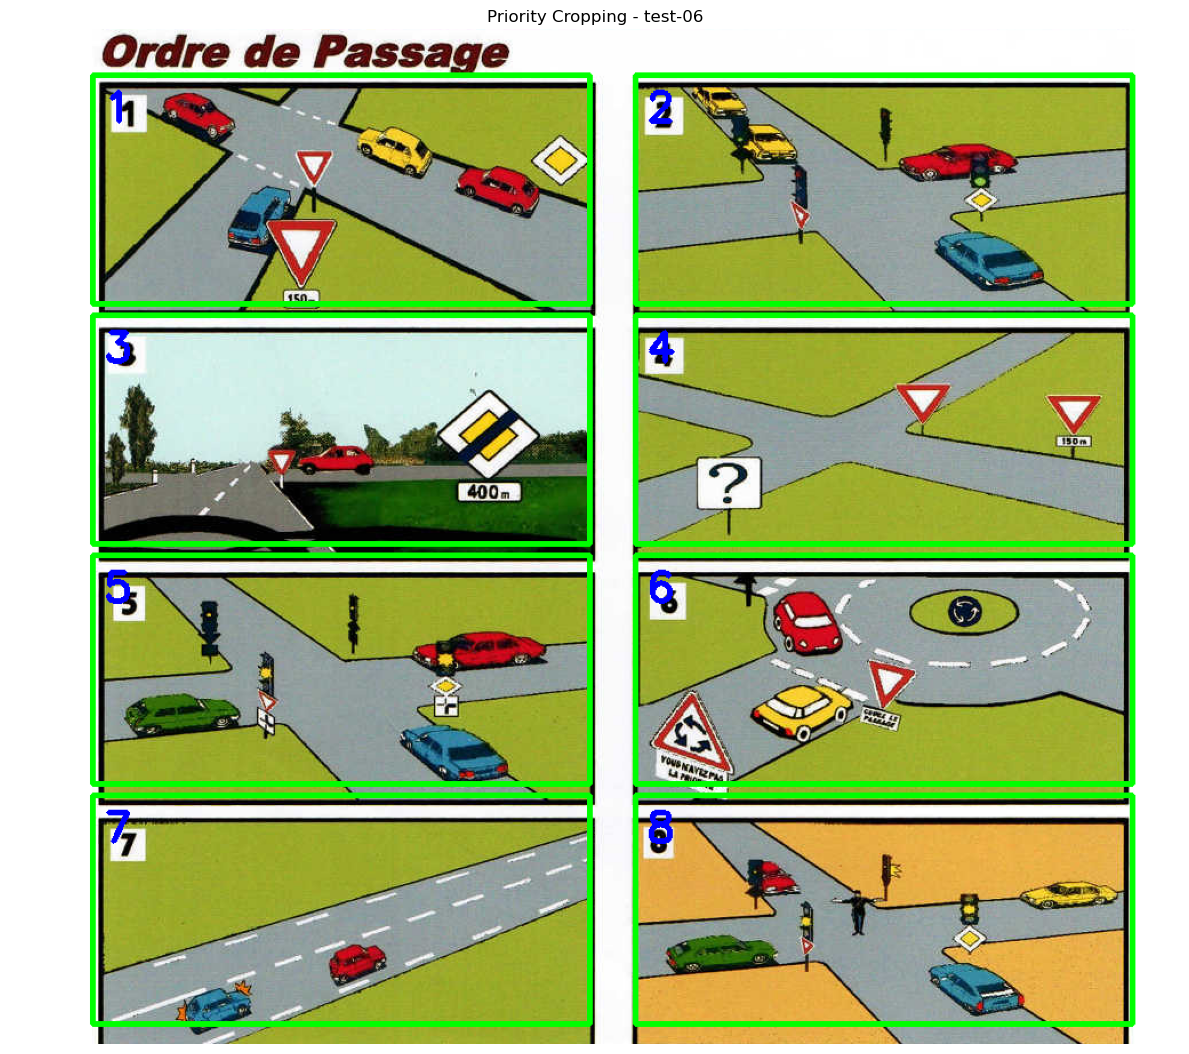

Visualization on: test-06_priorities.png
Image shape: (888, 1024, 3)


In [48]:
# Visualize cropping on a sample image
if test_dirs:
    sample_test = test_dirs[5]
    sample_priorities_dir = sample_test / "PRIORITIES"
    
    if sample_priorities_dir.exists():
        priorities_files = list(sample_priorities_dir.glob("*.png"))
        
        if priorities_files:
            sample_img_path = priorities_files[0]
            sample_img = cv2.imread(str(sample_img_path))
            
            boxes = calculate_boxes_fixed_grid(sample_img)
            
            # Draw boxes
            img_copy = sample_img.copy()
            for i, (x1, y1, x2, y2) in enumerate(boxes):
                cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 3)
                cv2.putText(img_copy, str(i+1), (x1+10, y1+40), 
                           cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 0, 0), 3)
            
            # Display
            plt.figure(figsize=(12, 16))
            plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
            plt.title(f"Priority Cropping - {sample_test.name}")
            plt.axis('off')
            plt.tight_layout()
            plt.show()
            
            print(f"Visualization on: {sample_img_path.name}")
            print(f"Image shape: {sample_img.shape}")

## 6. Display Cropped Results

Show all 8 cropped priority images from a sample test.

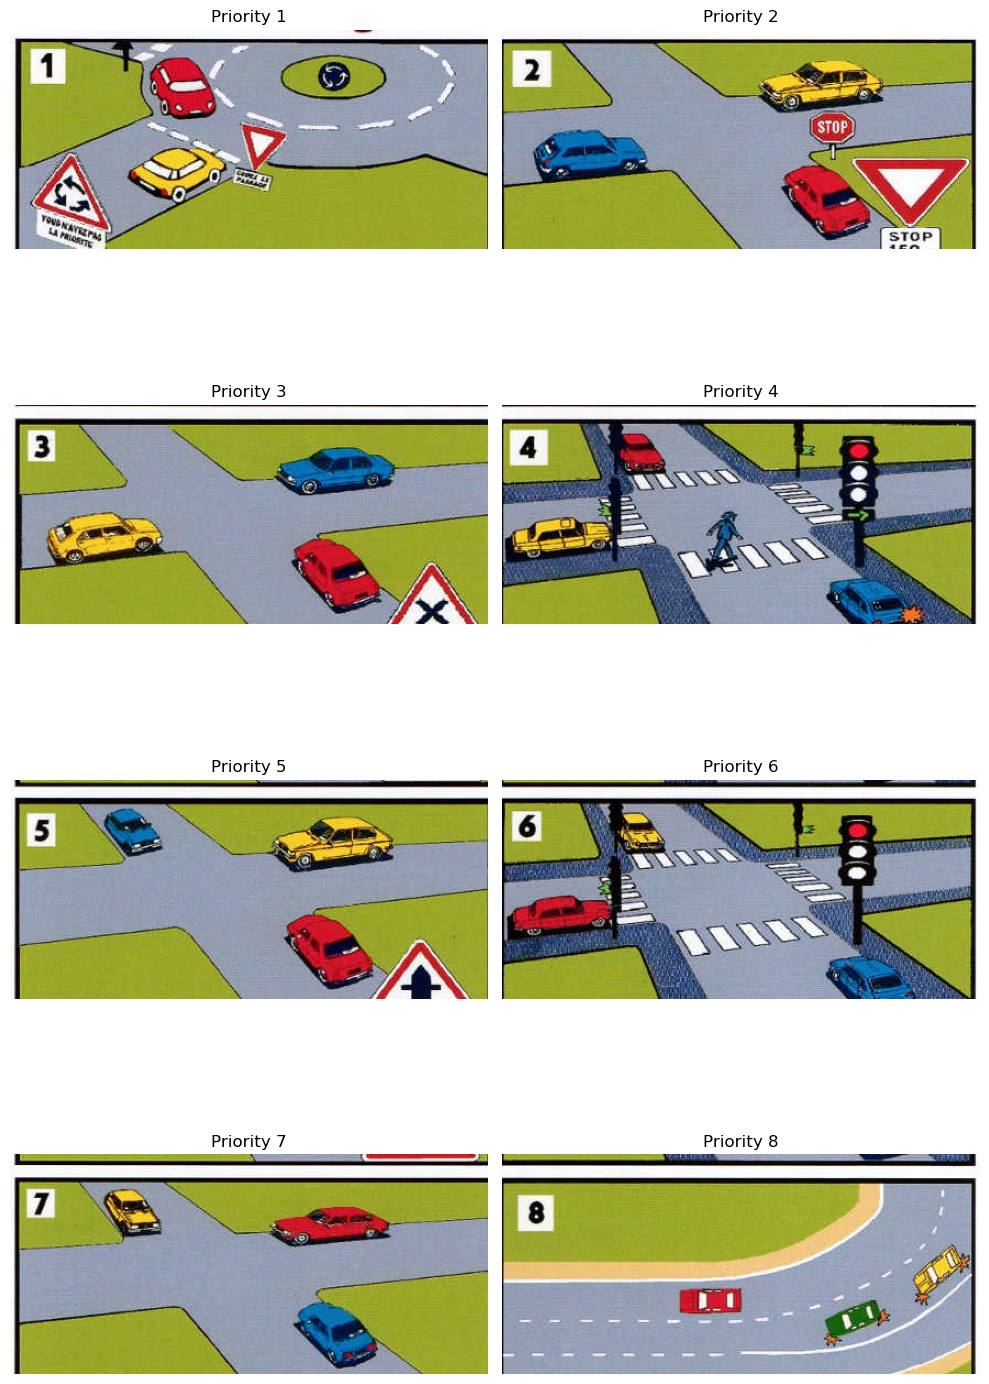

Displayed 8 priorities from: test-01


In [52]:
# Display all 8 cropped priorities from first test
if test_dirs and OUTPUT_DIR.exists():
    sample_test = test_dirs[0]
    sample_output_dir = OUTPUT_DIR / sample_test.name
    
    if sample_output_dir.exists():
        priority_files = sorted(sample_output_dir.glob("*.png"))
        
        if len(priority_files) == 8:
            fig, axes = plt.subplots(4, 2, figsize=(10, 16))
            axes = axes.flatten()
            
            for i, priority_path in enumerate(priority_files):
                priority_img = cv2.imread(str(priority_path))
                axes[i].imshow(cv2.cvtColor(priority_img, cv2.COLOR_BGR2RGB))
                axes[i].set_title(f"Priority {i+1}")
                axes[i].axis('off')
            
            plt.tight_layout()
            plt.show()
            
            print(f"Displayed 8 priorities from: {sample_test.name}")